In [329]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
import torch.nn.functional as F

In [330]:
!pip install scikit-learn

In [331]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if(torch.cuda.is_available()):
    print(f"GPU available: {torch.cuda.get_device_name()}")
    gpu = True
else:
    print("No GPU available")

GPU available: NVIDIA GeForce RTX 5050 Laptop GPU


In [332]:
matches_path = "data/Matches.csv"

df = pd.read_csv(matches_path)
print(df.shape)

(230557, 48)


/tmp/ipykernel_213008/4087795544.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(matches_path)


In [ ]:
features_to_drop = [
    'HTResult', 'OddHome', 'OddDraw', 
    'OddAway', 'MaxHome', 'MaxDraw', 'MaxAway', 
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 
    'HandiSize', 'HandiHome', 'HandiAway', 
    'C_HTB', 'C_PHB', 
]

thin_df = df.drop(features_to_drop, axis="columns")
thin_df = thin_df.dropna()
print(thin_df.shape)
thin_df.info()

(31426, 34)
<class 'pandas.DataFrame'>
Index: 31426 entries, 162577 to 230556
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Division     31426 non-null  str    
 1   MatchDate    31426 non-null  str    
 2   MatchTime    31426 non-null  str    
 3   HomeTeam     31426 non-null  str    
 4   AwayTeam     31426 non-null  str    
 5   HomeElo      31426 non-null  float64
 6   AwayElo      31426 non-null  float64
 7   Form3Home    31426 non-null  float64
 8   Form5Home    31426 non-null  float64
 9   Form3Away    31426 non-null  float64
 10  Form5Away    31426 non-null  float64
 11  FTHome       31426 non-null  float64
 12  FTAway       31426 non-null  float64
 13  FTResult     31426 non-null  str    
 14  HTHome       31426 non-null  float64
 15  HTAway       31426 non-null  float64
 16  HomeShots    31426 non-null  float64
 17  AwayShots    31426 non-null  float64
 18  HomeTarget   31426 non-null  float64
 19  Aw

### Compute Attacking and Correctness Coefficients

Coefficients based on the following metrics:
- **Pericolosity:** the amount of offensive game created considering the number of corners, shots, shots on target and goals (weighted).
- **Correctness:** the amount of infractions committed considering the number of fouls, yellow and red cards (weighted) by a team.

In [334]:
thin_df['AttackingCoefficientHome'] = 1*thin_df["HomeCorners"] + 3*thin_df['HomeShots'] + 5*thin_df['HomeTarget'] + 10*thin_df['FTHome']  
thin_df['AttackingCoefficientAway'] = 1*thin_df["AwayCorners"] + 3*thin_df['AwayShots'] + 5*thin_df['AwayTarget'] + 10*thin_df['FTAway']

thin_df['CorrectnessCoefficientHome'] = 1*thin_df["HomeFouls"] + 5*thin_df['HomeYellow'] + 15*thin_df['HomeRed']
thin_df['CorrectnessCoefficientAway'] = 1*thin_df["AwayFouls"] + 5*thin_df['AwayYellow'] + 15*thin_df['AwayRed']
thin_df = thin_df.drop(columns=["HomeFouls", "HomeYellow", "HomeRed", "AwayFouls", "AwayYellow", "AwayRed", "HomeCorners", "AwayCorners"])
thin_df.info()

<class 'pandas.DataFrame'>
Index: 31426 entries, 162577 to 230556
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Division                    31426 non-null  str    
 1   MatchDate                   31426 non-null  str    
 2   MatchTime                   31426 non-null  str    
 3   HomeTeam                    31426 non-null  str    
 4   AwayTeam                    31426 non-null  str    
 5   HomeElo                     31426 non-null  float64
 6   AwayElo                     31426 non-null  float64
 7   Form3Home                   31426 non-null  float64
 8   Form5Home                   31426 non-null  float64
 9   Form3Away                   31426 non-null  float64
 10  Form5Away                   31426 non-null  float64
 11  FTHome                      31426 non-null  float64
 12  FTAway                      31426 non-null  float64
 13  FTResult                    31426 non-nul

In [335]:
def compute_avg(df, group_ft, feature, n = 5):
    """
        INPUT:
            df: dataframe,
            group_ft: feature that groups the samples for the avg,
            feature: feature to compute the avarage of
            n: consecutive values to consider for the avg
    """
    avg = df.groupby(group_ft)[feature].shift(1).rolling(window=n, min_periods=1).mean()
    return avg
    # 'C_HTB', 'C_PHB',    

df_home = thin_df[["MatchDate", "HomeTeam", "HomeShots", "FTHome", "FTAway", "HomeTarget", "HTHome", "AttackingCoefficientHome", "CorrectnessCoefficientHome", 'C_LTH', 'C_VHD']].copy()
df_home = df_home.rename(columns={
    'HomeTeam': 'team',
    'FTHome': 'goals',
    'HTHome': 'goals_ht',
    'HomeShots': 'shots',
    'HomeTarget': 'target',
    'FTAway': 'conceded',
    'AttackingCoefficientHome': 'pericolosity',
    'CorrectnessCoefficientHome': 'correctness',
    'C_LTH': 'lowTempo',
    'C_VHD': 'visiblyDominated'
})

df_away = thin_df[["MatchDate", "AwayTeam", "AwayShots", "FTAway", "FTHome", "HTAway", "AwayTarget", "AttackingCoefficientAway", "CorrectnessCoefficientAway", 'C_LTA', 'C_VAD']].copy()    
df_away = df_away.rename(columns={
    'AwayTeam': 'team',
    'FTAway': 'goals',
    'HTAway': 'goals_ht',
    'AwayShots': 'shots',
    'AwayTarget': 'target',
    'FTHome': 'conceded',
    'AttackingCoefficientAway': 'pericolosity',
    'CorrectnessCoefficientAway': 'correctness',
    'C_LTA': 'lowTempo',
    'C_VAD': 'visiblyDominated'
})

cat_df = pd.concat([df_home, df_away])

# at this point in cat_df we have the list matches for teams grouped by and sorted
cat_df = cat_df.sort_values(by=['team', 'MatchDate'])
cat_df.info()

<class 'pandas.DataFrame'>
Index: 62852 entries, 172290 to 230426
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MatchDate         62852 non-null  str    
 1   team              62852 non-null  str    
 2   shots             62852 non-null  float64
 3   goals             62852 non-null  float64
 4   conceded          62852 non-null  float64
 5   target            62852 non-null  float64
 6   goals_ht          62852 non-null  float64
 7   pericolosity      62852 non-null  float64
 8   correctness       62852 non-null  float64
 9   lowTempo          62852 non-null  float64
 10  visiblyDominated  62852 non-null  float64
dtypes: float64(9), str(2)
memory usage: 5.8 MB


In [336]:
cat_df['Form5Shots'] = compute_avg(cat_df, 'team', 'shots')
cat_df['Form5Target'] = compute_avg(cat_df, 'team', 'target')
cat_df['Form5Goals'] = compute_avg(cat_df, 'team', 'goals')
cat_df['Form5GoalsHT'] = compute_avg(cat_df, 'team', 'goals_ht')
cat_df['Form5GoalsConceded'] = compute_avg(cat_df, 'team', 'conceded')
cat_df['Form5Pericolosity'] = compute_avg(cat_df, 'team', 'pericolosity')
cat_df['Form5Correctness'] = compute_avg(cat_df, 'team', 'correctness')
cat_df['Form5lowTempo'] = compute_avg(cat_df, 'team', 'lowTempo')
cat_df['Form5visiblyDominated'] = compute_avg(cat_df, 'team', 'visiblyDominated')

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'HomeTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    'Form5Shots': 'Form5ShotsHome',
    'Form5Target': 'Form5TargetHome',
    'Form5Goals': 'Form5GoalsHome',
    'Form5GoalsHT': 'Form5GoalsHTHome',
    'Form5GoalsConceded': 'Form5GoalsConcededHome',
    'Form5Pericolosity': 'Form5PericolosityHome',
    'Form5Correctness': 'Form5CorrectnessHome',
    'Form5lowTempo': 'Form5lowTempoHome',
    'Form5visiblyDominated': 'Form5visiblyDominatedHome'
    })
thin_df = thin_df.drop(columns=['team', 'goals', 'shots', 'target', 'goals_ht','conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated'])

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'AwayTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    'Form5Shots': 'Form5ShotsAway',
    'Form5Target': 'Form5TargetAway',
    'Form5Goals': 'Form5GoalsAway',
    'Form5GoalsHT': 'Form5GoalsHTAway',
    'Form5GoalsConceded': 'Form5GoalsConcededAway',
    'Form5Pericolosity': 'Form5PericolosityAway',
    'Form5Correctness': 'Form5CorrectnessAway',
    'Form5lowTempo': 'Form5lowTempoAway',
    'Form5visiblyDominated': 'Form5visiblyDominatedAway'
})
thin_df = thin_df.drop(columns=['team', 'goals', 'shots', 'goals_ht', 'target', 'conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated'])

In [337]:
drop_columns = [
    'HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget', 'FTHome', 'FTAway',
    'AttackingCoefficientHome', 'AttackingCoefficientAway', 'HTHome', 'HTAway',
    'CorrectnessCoefficientHome', 'CorrectnessCoefficientAway', 
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD'
]

thin_df = thin_df.drop(columns=drop_columns)


In [338]:
df = thin_df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 31425 entries, 0 to 31425
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Division                   31425 non-null  str    
 1   MatchDate                  31425 non-null  str    
 2   MatchTime                  31425 non-null  str    
 3   HomeTeam                   31425 non-null  str    
 4   AwayTeam                   31425 non-null  str    
 5   HomeElo                    31425 non-null  float64
 6   AwayElo                    31425 non-null  float64
 7   Form3Home                  31425 non-null  float64
 8   Form5Home                  31425 non-null  float64
 9   Form3Away                  31425 non-null  float64
 10  Form5Away                  31425 non-null  float64
 11  FTResult                   31425 non-null  str    
 12  C_HTB                      31425 non-null  float64
 13  C_PHB                      31425 non-null  float64
 14  Form5S

In [339]:
df["Form3Difference"] = df["Form3Home"] - df["Form3Away"]
df["Form5Difference"] = df["Form5Home"] - df["Form5Away"]

In [340]:
# DROPPING THESE FEATURES SINCE THEY HAVE NO CORRELATION WITH OTHER FEATURES

#time_parts = df.iloc[:, 2].str.split(":", expand=True)
#
#df['Hour'] = time_parts[0].astype('int8')
#df['Minutes'] = time_parts[1].astype('int8')
#
# in the end we drop the previous features stored as strings.
df_min = df.drop(columns=["MatchDate", "MatchTime", "HomeTeam", "AwayTeam", "Division"])

In [341]:
# define an array of unique team names' string.
unique_teams = [x for x in df['HomeTeam'].unique()]

print(unique_teams)
print(len(unique_teams))

['Ajaccio', 'Chambly', 'Clermont', 'Guingamp', 'Nancy', 'Niort', 'Rodez', 'Sochaux', 'Genk', 'Stuttgart', 'Dresden', 'Le Mans', 'Holstein Kiel', 'Osnabruck', 'Cercle Brugge', 'St Truiden', 'Waregem', 'Hamburg', 'Anderlecht', 'Greuther Furth', 'Regensburg', 'Wehen', 'Charleroi', 'Eupen', 'Bielefeld', 'Lorient', 'Bochum', 'Sandhausen', 'Auxerre', 'Chateauroux', 'Grenoble', 'Le Havre', 'Orleans', 'Paris FC', 'Troyes', 'Valenciennes', 'Zwolle', 'St Pauli', 'Club Brugge', 'Luton', 'Karlsruhe', 'Hannover', 'Celtic', 'Hibernian', 'Livingston', 'Ross County', 'Barnsley', 'Blackburn', 'Brentford', 'Millwall', 'Reading', 'Stoke', 'Swansea', 'Wigan', 'Lens', 'Standard', 'FC Emmen', 'Vitesse', 'Nottm Forest', 'Kortrijk', 'Oostende', 'Mechelen', 'Twente', 'VVV Venlo', 'Heracles', 'Heidenheim', 'Kilmarnock', 'Gent', 'Feyenoord', 'Darmstadt', 'Erzgebirge Aue', 'Aberdeen', 'Den Haag', 'Bristol City', 'Mouscron', 'AZ Alkmaar', 'Nurnberg', 'Huddersfield', 'Caen', 'Sparta Rotterdam', 'Monaco', 'Liverpool

In [342]:
# code taken from the https://gist.github.com/GavinXing/9954ea846072e115bb07d9758892382c
# so far we are not using it since for simplicity we drop the TeamNames columns from the dataset

class CBOW(nn.Module):

    def __init__(self, context_size=2, embedding_size=100, vocab_size=None):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        self.linear1 = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs):
        lookup_embeds = self.embeddings(inputs)
        embeds = lookup_embeds.sum(dim=0)
        out = self.linear1(embeds)
        out = F.log_softmax(out)
        return out
    
def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    tensor = torch.LongTensor(idxs)
    return autograd.Variable(tensor)

In [343]:
vocab = set(unique_teams)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []

In [344]:
result_mapping = {'H': 0, 'D': 1, 'A': 2}
df_min['Target'] = df_min['FTResult'].map(result_mapping).astype('int8')

df_min = df_min.drop(columns=["FTResult"])
df_min.info()

<class 'pandas.DataFrame'>
Index: 31425 entries, 0 to 31425
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   HomeElo                    31425 non-null  float64
 1   AwayElo                    31425 non-null  float64
 2   Form3Home                  31425 non-null  float64
 3   Form5Home                  31425 non-null  float64
 4   Form3Away                  31425 non-null  float64
 5   Form5Away                  31425 non-null  float64
 6   C_HTB                      31425 non-null  float64
 7   C_PHB                      31425 non-null  float64
 8   Form5ShotsHome             31425 non-null  float64
 9   Form5TargetHome            31425 non-null  float64
 10  Form5GoalsHome             31425 non-null  float64
 11  Form5GoalsHTHome           31425 non-null  float64
 12  Form5GoalsConcededHome     31425 non-null  float64
 13  Form5PericolosityHome      31425 non-null  float64
 14  Form5C

In [345]:
df_min

,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,C_HTB,C_PHB,Form5ShotsHome,Form5TargetHome,...,Form5GoalsAway,Form5GoalsHTAway,Form5GoalsConcededAway,Form5PericolosityAway,Form5CorrectnessAway,Form5lowTempoAway,Form5visiblyDominatedAway,Form3Difference,Form5Difference,Target
0,1360.18,1438.67,4.0,4.0,1.0,4.0,0.0443,0.5888,10.25,3.75,...,1.50,0.25,1.25,84.5,32.25,0.086375,0.364050,3.0,0.0,1
1,1315.69,1361.10,0.0,0.0,4.0,5.0,0.0640,0.1689,10.00,3.00,...,1.50,1.00,1.00,66.0,23.25,0.337775,0.037900,-4.0,-5.0,0
2,1414.77,1396.05,1.0,3.0,7.0,11.0,0.1500,0.0381,14.75,3.50,...,0.50,0.25,0.50,50.5,22.75,0.356450,0.197725,-6.0,-8.0,0
3,1471.61,1364.04,2.0,3.0,1.0,5.0,0.0105,0.0637,18.50,5.00,...,1.25,0.75,1.50,88.0,25.50,0.119025,0.159875,1.0,-2.0,1
4,1364.51,1380.99,3.0,9.0,1.0,1.0,0.0203,0.0488,17.00,4.25,...,0.50,0.25,3.50,85.0,21.75,0.164250,0.260900,2.0,8.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31421,1339.21,1544.15,3.0,6.0,7.0,13.0,0.1386,0.0104,6.60,2.80,...,1.60,0.40,0.80,85.2,20.40,0.303560,0.096100,-4.0,-7.0,2
31422,1544.16,1433.67,4.0,10.0,1.0,3.0,0.2332,0.0274,14.80,5.00,...,0.40,0.20,0.80,46.0,38.40,0.205480,0.184360,3.0,7.0,0
31423,1473.67,1569.98,0.0,3.0,3.0,7.0,0.0180,0.0813,12.60,3.20,...,1.20,0.40,1.20,76.4,30.20,0.284600,0.201960,-3.0,-4.0,2
31424,1574.90,1525.76,7.0,13.0,6.0,9.0,0.2634,0.0261,9.60,2.80,...,1.80,1.00,1.20,69.0,24.40,0.167140,0.150160,1.0,4.0,0


### Pairplot and Correlation Matrix

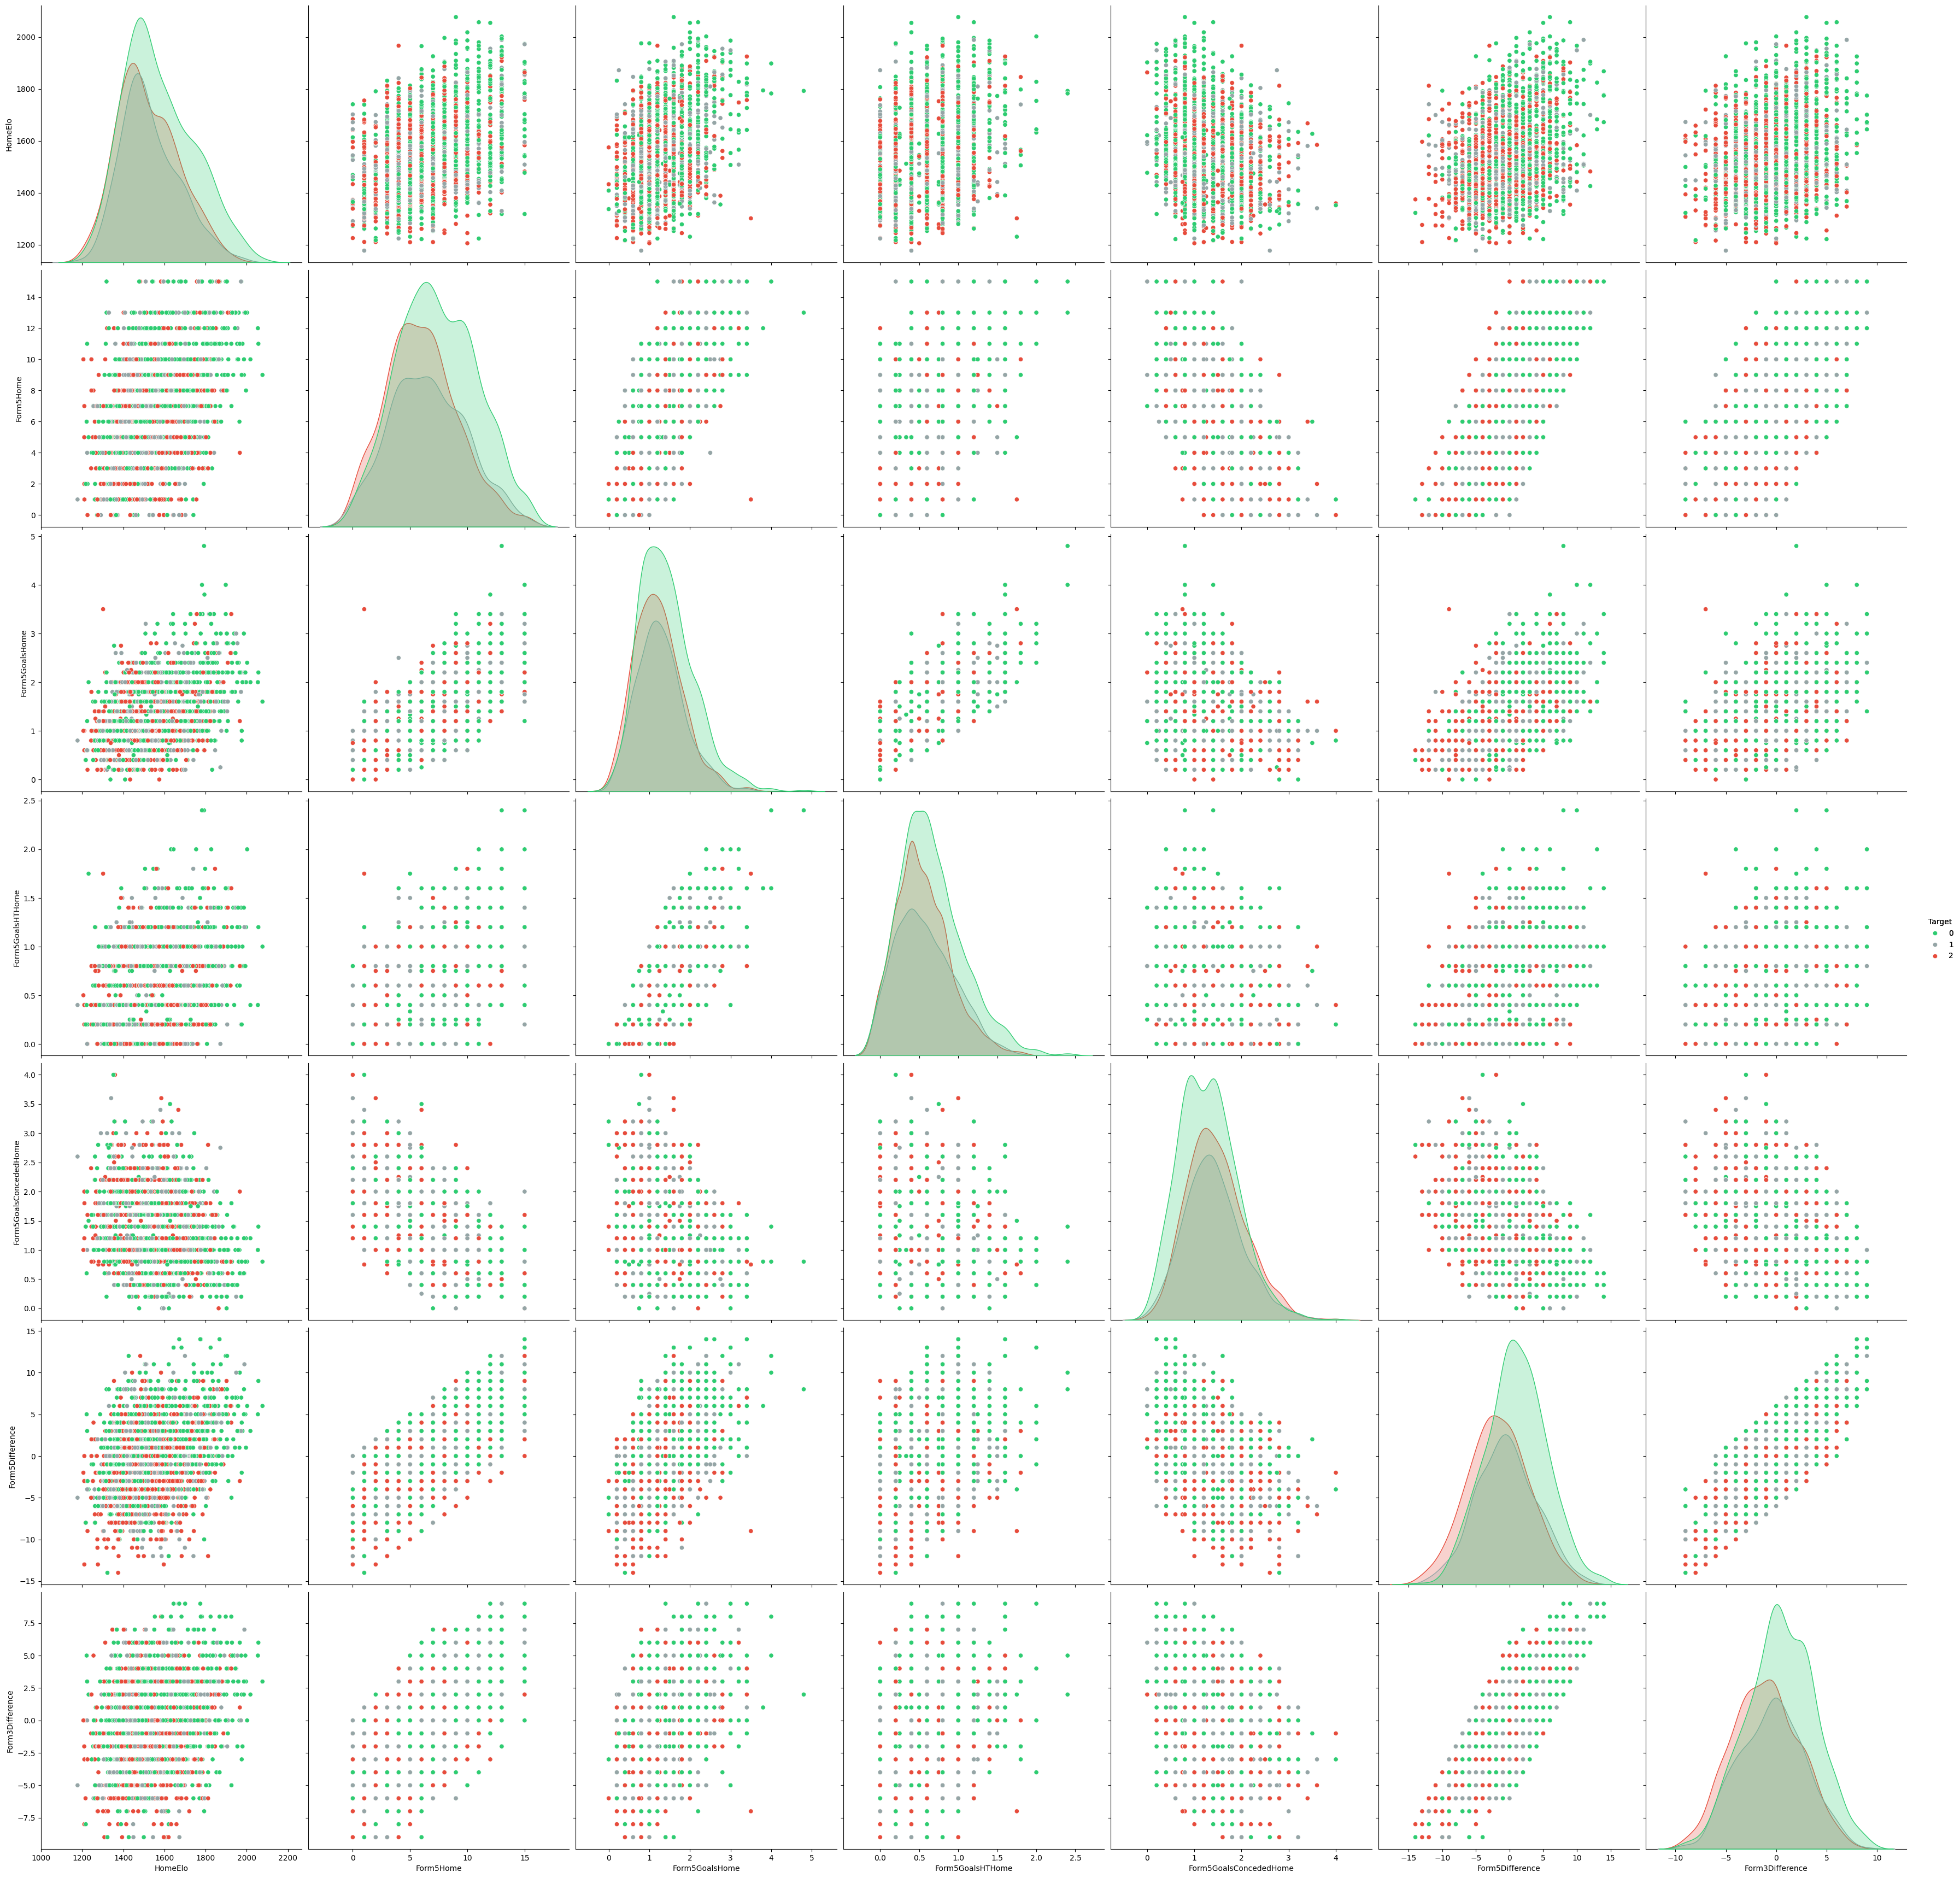

In [346]:
import seaborn as sns

cols_relation = [
    'HomeElo', 'Form5Home', 'Form5GoalsHome', 'Form5GoalsHTHome', 'Form5GoalsConcededHome', 'Form5Difference', 'Form3Difference'
]
random_df = df_min.sample(2000)

sns.pairplot(random_df, x_vars=cols_relation, y_vars=cols_relation, hue="Target", palette=['#2ecc71', '#95a5a6', '#e74c3c'], height=5).add_legend()

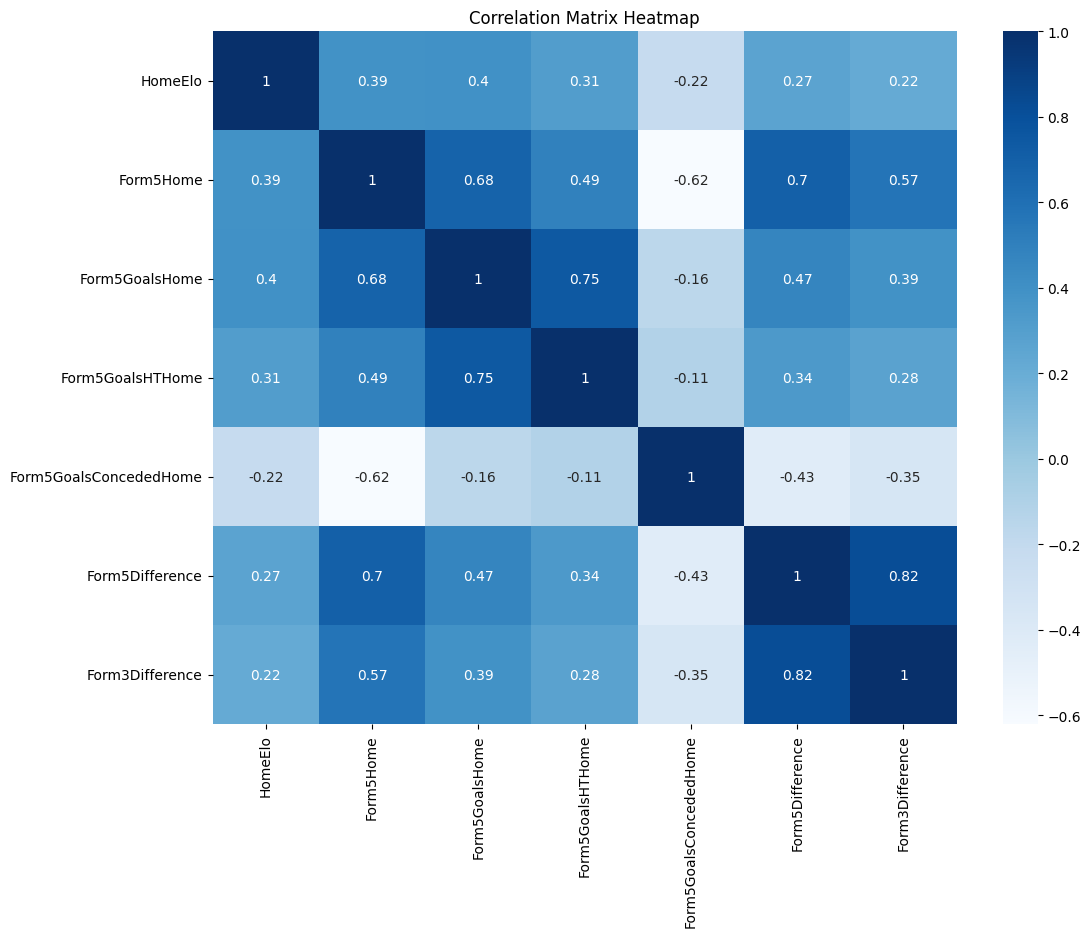

In [347]:
corrmat = df_min[cols_relation].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corrmat, cmap="Blues",annot=True);
plt.title('Correlation Matrix Heatmap')
plt.show()

### Define Training/Eval/Test Sets

In [348]:
from torch.utils.data import TensorDataset, DataLoader

num_features = df_min.shape[1] - 1
print(num_features)

y_labels = df_min.iloc[:, num_features]
X_features = df_min.drop(df_min.columns[num_features], axis=1)

28


In [349]:
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    X_features, y_labels, test_size=0.20, random_state=42, shuffle=False
)

X_train, x_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(X_train.shape)
print(x_eval.shape)
print(X_test.shape)

(20112, 28)
(5028, 28)
(6285, 28)


In [350]:
scaler = StandardScaler()

# scale data based on the mean and std of the training data
X_train = scaler.fit_transform(X_train) # computes mean and std of training set
X_test = scaler.transform(X_test)
x_eval = scaler.transform(x_eval)

In [351]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

X_eval = torch.tensor(x_eval, dtype=torch.float32)
y_eval = torch.tensor(y_eval.values, dtype=torch.long)

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=False)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
eval_dataloader = DataLoader(TensorDataset(X_eval, y_eval), batch_size=64, shuffle=False)


### Model Definition

In [352]:
class ModelClassifier(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.lin1 = nn.Linear(num_features, out_features=128) # linear applies x * W^T + b
        self.bn1 = nn.BatchNorm1d(128)
        
        self.lin2 = nn.Linear(128, out_features=64)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.lin3 = nn.Linear(64, out_features=32)
        self.bn3 = nn.BatchNorm1d(32)
    
        self.lin4 = nn.Linear(32, out_features=16)
        self.bn4 = nn.BatchNorm1d(16)
        
        self.output_layer = nn.Linear(16, out_features=3) # output layer
        
        self.hidden_act = nn.LeakyReLU(negative_slope=0.1)
        # self.output_act = nn.Softmax() # defines the SoftMax behaviour for more than 2 classes classification
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        """
            Forward pass for the model. BatchNorm NOT activated.
        """        
        # activation of the first layer
        x = self.lin1(x)
        #x = self.bn1(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        # activation of the second layer
        x = self.lin2(x)
        #x = self.bn2(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.lin3(x)
        #x = self.bn3(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.lin4(x)
        #x = self.bn4(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.output_layer(x)        
        return x

Define some usefull elements for the training like:
- Initialize the model;
- Initialize hyperparameters (learning rate, weight decay);
- Initialize Optimizers;

In [353]:
EPOCHS = 100
EPOCHS_STOP = 5

lr = 1e-01
weight_decay = 0
weight_result = True
weights = torch.tensor([1.0, 1.20, 1.00]).to(device) if weight_result else None

criterion = nn.CrossEntropyLoss(weight=weights) # adding weights in order to make some predictions more predictable (model never predicts 1 so far)
model = ModelClassifier(num_features=num_features)
model.to(device)
model.train(True)

optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=0,
)
lr_scheduler = optim.lr_scheduler.MultiplicativeLR(
    optimizer=optimizer,
    lr_lambda= lambda epoch: 0.95
)

### EVAL FUNCTION 

In [354]:
def eval_model(model, dataloader, loss_fn, device):
    """
        Function that validates the model
        INPUTS:
            - model: our defined class model;
            - dataloader: an instance of the validation dataloader containing samples and labels;
            - loss_fn: loss function (just for health checking the results);
            - device: gpu or cpu boolean value.
    """
    
    model.eval()  # Set to evaluation mode

    total_loss = 0
    correct = 0
    samples = 0
    metrics = {} # further implementation
    
    with torch.no_grad():
        for input_batch, label_batch in dataloader:
            input_batch = input_batch.to(device)
            label_batch = label_batch.to(device)
            
            label_batch = label_batch.long()
            
            predict = model(input_batch)
            
            loss = loss_fn(predict, label_batch)
            
            total_loss += loss.item()
            predictions = torch.argmax(predict, dim=1)
            correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
            samples += label_batch.size(0) # Add batch size (e.g., 32)
            
                
    model.train()  # Set back to training mode
    metrics["Avg_loss"] = total_loss / len(dataloader)
    metrics["Accuracy"] = correct / samples
    
    return metrics

### TRAINING

In [ ]:
train_loss = []
eval_loss = []

# set these values for the early stopping
best_loss = float('inf')
count = 0
for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    for input_batch, label_batch in train_dataloader:
        input_batch = input_batch.to(device)
        label_batch = label_batch.to(device)
        
        label_batch = label_batch.long()
        
        logits = model(input_batch)
        
        # zero-out the gradients
        optimizer.zero_grad()
        loss = criterion(logits, label_batch)
        
        loss.backward() # perform backpropagation
        
        # compute the next step for the optimizer and the lr_scheduler
        optimizer.step()
        
        # compute total training loss and correct predictions
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
                
    metrics = eval_model(model, eval_dataloader, criterion, device=device)
    lr_scheduler.step()
    
    if epoch % 10 == 0:
        print(f"Loss for epoch nr. {epoch + 1}: {total_loss:.2f}")
        print(f"Correct predictions for epoch nr. {epoch + 1}: {correct}\n")
        
        #for logit, label in zip(logits, label_batch):
        #    prediction = F.softmax(logit, dim=0)
        #    print(f"Our prediction: {prediction}")
        #    print(f"True prediction: {label}")
        print(f"Eval Loss for epoch nr. {epoch + 1}: {metrics["Avg_loss"]:.2f}")
        print(f"Eval percentage of correct predictions for epoch nr. {epoch + 1}: {metrics["Accuracy"]*100:.2f}\n")
    
    train_loss.append(total_loss) # append loss relative to the epoch
    eval_loss.append(metrics["Avg_loss"])
        
    if total_loss < best_loss:
        best_loss = total_loss
        count = 0 # reset the count because we improved the loss## Decision Trees and Random Classifier
    else:
        count += 1
        
    # if count == EPOCHS_STOP:
    #     print(f"Early stopping at epoch nr. {epoch + 1}")
    #     break # we stop the training if we have no improvement   

mean_train_loss = np.mean(train_loss)
mean_eval_loss = np.mean(eval_loss)
print(f"Mean train loss: {mean_train_loss:.4f}")
print(f"Mean eval loss: {mean_eval_loss:.4f}")
    

Loss for epoch nr. 1: 2272.07
Correct predictions for epoch nr. 1: 6998

Eval Loss for epoch nr. 1: 1.17
Eval percentage of correct predictions for epoch nr. 1: 44.79

Loss for epoch nr. 11: 352.74
Correct predictions for epoch nr. 11: 7805

Eval Loss for epoch nr. 11: 1.05
Eval percentage of correct predictions for epoch nr. 11: 45.51

Loss for epoch nr. 21: 560.54
Correct predictions for epoch nr. 21: 6992

Eval Loss for epoch nr. 21: 1.25
Eval percentage of correct predictions for epoch nr. 21: 33.23

Loss for epoch nr. 31: 352.43
Correct predictions for epoch nr. 31: 7675

Eval Loss for epoch nr. 31: 1.08
Eval percentage of correct predictions for epoch nr. 31: 44.79

Loss for epoch nr. 41: 345.83
Correct predictions for epoch nr. 41: 8121

Eval Loss for epoch nr. 41: 1.07
Eval percentage of correct predictions for epoch nr. 41: 44.79



## Decision Trees and Random Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report

tree_models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10) # n of estimators to 100 --> Decision trees in the forest
}

In [ ]:
tree_metrics = []
max_depth_values = [3, 5, 8, 10, 20, 25]

for k in max_depth_values:
    for name, tree_model in tree_models.items():
        print(f"Starting to fit the training set with the {name} method with max_depth={k}")
        tree_model.set_params(max_depth=k)
        
        tree_model.fit(X_train, y_train)
        
        prediction = tree_model.predict(X_eval)
        
        accuracy = accuracy_score(y_eval, prediction)
        
        # calculate the prediction for all three classes
        precision = precision_score(y_eval, prediction, average='macro', zero_division=0)
        
        metrics = {
            'method': name,
            'max_depth': k,
            'accuracy': accuracy,
            'precision': precision
        }
        tree_metrics.append(metrics)

print("Completed.")

Starting to fit the training set with the DecisionTree method with max_depth=3
Starting to fit the training set with the RandomForest method with max_depth=3
Starting to fit the training set with the DecisionTree method with max_depth=5
Starting to fit the training set with the RandomForest method with max_depth=5
Starting to fit the training set with the DecisionTree method with max_depth=8
Starting to fit the training set with the RandomForest method with max_depth=8
Starting to fit the training set with the DecisionTree method with max_depth=10
Starting to fit the training set with the RandomForest method with max_depth=10
Starting to fit the training set with the DecisionTree method with max_depth=20
Starting to fit the training set with the RandomForest method with max_depth=20
Starting to fit the training set with the DecisionTree method with max_depth=25
Starting to fit the training set with the RandomForest method with max_depth=25
Completed.


In [ ]:
def print_metrics(metric):
    print(f"Method: {metric["method"]}")
    print(f"Max Depth: {metric["max_depth"]}")
    print(f"Accuracy: {metric["accuracy"]*100:.2f}%")
    print(f"Precision: {metric["precision"]*100:.2f}%\n")
    
for metric in tree_metrics:
    print_metrics(metric)

Method: DecisionTree
Max Depth: 3
Accuracy: 46.69%
Precision: 29.91%

Method: RandomForest
Max Depth: 3
Accuracy: 47.94%
Precision: 31.81%

Method: DecisionTree
Max Depth: 5
Accuracy: 48.72%
Precision: 40.28%

Method: RandomForest
Max Depth: 5
Accuracy: 48.26%
Precision: 31.81%

Method: DecisionTree
Max Depth: 8
Accuracy: 48.12%
Precision: 42.49%

Method: RandomForest
Max Depth: 8
Accuracy: 48.77%
Precision: 48.59%

Method: DecisionTree
Max Depth: 10
Accuracy: 46.85%
Precision: 42.49%

Method: RandomForest
Max Depth: 10
Accuracy: 48.93%
Precision: 47.16%

Method: DecisionTree
Max Depth: 20
Accuracy: 40.88%
Precision: 38.42%

Method: RandomForest
Max Depth: 20
Accuracy: 48.91%
Precision: 43.46%

Method: DecisionTree
Max Depth: 25
Accuracy: 40.30%
Precision: 38.35%

Method: RandomForest
Max Depth: 25
Accuracy: 48.51%
Precision: 42.86%

